In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [8]:
words = open(file='./data/names.txt', mode = 'r').read().splitlines()
# print(words

In [21]:
chars = sorted(set(''.join(words)))
stoi = {k :v+1 for v, k in enumerate(chars)}
stoi['.'] = 0
itos = {k: v for v, k in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [41]:
build_size = 3
X, Y = [], []
for w in words:
    context = [0] * build_size
    # print(w)
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context),'----->', itos[ix])
        context = context[1:] + [ix]
X = torch.tensor(X).float()
Y = torch.tensor(Y).long()
print(X.shape, Y.shape)

torch.Size([228146, 3]) torch.Size([228146])


In [151]:
### We can adjust the window 
build_size = 3
X, Y = [], []
for w in words:
    chs = w + '.'
    context = [0] * build_size
    for i in chs:
        ix = stoi[i]
        X.append(context)
        Y.append(ix)
        # print(''.join([itos[ix] for ix in context]),'----->',i)
        context = context[1:] + [ix]
X = torch.tensor(X).long()
Y = torch.tensor(Y).long()

In [152]:
### lookup table
C = torch.randn(size=[27,2])

In [153]:
F.one_hot(torch.tensor(5), num_classes= 27).float() @ C

tensor([-1.5408, -0.6291])

In [154]:
C[5,:] ## 索引
C[1:5,:] ## 切片
C[[1,2],:]

tensor([[-0.5890, -0.3415],
        [-1.4220,  0.2251]])

In [155]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        ...,
        [26, 26, 25],
        [26, 25, 26],
        [25, 26, 24]])

In [156]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        ...,
        [26, 26, 25],
        [26, 25, 26],
        [25, 26, 24]])

In [159]:
emb = C[X]
W1 = torch.randn(size=[6,100])
b2 = torch.randn(100)

In [160]:
C[X][:,0,:] ### 二维 索引

tensor([[ 1.2573,  0.7387],
        [ 1.2573,  0.7387],
        [ 1.2573,  0.7387],
        ...,
        [-1.7688,  2.0316],
        [-1.7688,  2.0316],
        [-0.7097,  0.3300]])

In [161]:
torch.cat((C[X][:,0,:], C[X][:,1,:], C[X][:,2,:]), dim= 1)

tensor([[ 1.2573,  0.7387,  1.2573,  0.7387,  1.2573,  0.7387],
        [ 1.2573,  0.7387,  1.2573,  0.7387, -1.5408, -0.6291],
        [ 1.2573,  0.7387, -1.5408, -0.6291,  0.7077, -1.1490],
        ...,
        [-1.7688,  2.0316, -1.7688,  2.0316, -0.7097,  0.3300],
        [-1.7688,  2.0316, -0.7097,  0.3300, -1.7688,  2.0316],
        [-0.7097,  0.3300, -1.7688,  2.0316,  1.8558, -1.2552]])

In [164]:
emb.flatten(1)

tensor([[ 1.2573,  0.7387,  1.2573,  0.7387,  1.2573,  0.7387],
        [ 1.2573,  0.7387,  1.2573,  0.7387, -1.5408, -0.6291],
        [ 1.2573,  0.7387, -1.5408, -0.6291,  0.7077, -1.1490],
        ...,
        [-1.7688,  2.0316, -1.7688,  2.0316, -0.7097,  0.3300],
        [-1.7688,  2.0316, -0.7097,  0.3300, -1.7688,  2.0316],
        [-0.7097,  0.3300, -1.7688,  2.0316,  1.8558, -1.2552]])

In [165]:
import torch.nn as nn
nn.Flatten()(emb)

tensor([[ 1.2573,  0.7387,  1.2573,  0.7387,  1.2573,  0.7387],
        [ 1.2573,  0.7387,  1.2573,  0.7387, -1.5408, -0.6291],
        [ 1.2573,  0.7387, -1.5408, -0.6291,  0.7077, -1.1490],
        ...,
        [-1.7688,  2.0316, -1.7688,  2.0316, -0.7097,  0.3300],
        [-1.7688,  2.0316, -0.7097,  0.3300, -1.7688,  2.0316],
        [-0.7097,  0.3300, -1.7688,  2.0316,  1.8558, -1.2552]])

In [166]:
torch.cat(torch.unbind(emb, dim=1),dim = 1)

tensor([[ 1.2573,  0.7387,  1.2573,  0.7387,  1.2573,  0.7387],
        [ 1.2573,  0.7387,  1.2573,  0.7387, -1.5408, -0.6291],
        [ 1.2573,  0.7387, -1.5408, -0.6291,  0.7077, -1.1490],
        ...,
        [-1.7688,  2.0316, -1.7688,  2.0316, -0.7097,  0.3300],
        [-1.7688,  2.0316, -0.7097,  0.3300, -1.7688,  2.0316],
        [-0.7097,  0.3300, -1.7688,  2.0316,  1.8558, -1.2552]])

In [167]:
### hidden state 
h = torch.tanh(emb.view(emb.size(0), -1) @ W1 + b2)
h.shape

torch.Size([228146, 100])

In [168]:
W2 = torch.randn(size=(100,27))
b2 = torch.randn(27)

logits = h @ W2 + b2

In [169]:
counts = logits.exp()
probs = counts / counts.sum(dim= 1, keepdim= True)
probs[0]

tensor([6.4883e-05, 1.8045e-13, 4.4683e-07, 5.6593e-02, 4.3905e-01, 4.2232e-05,
        4.8685e-01, 2.2218e-05, 1.1801e-09, 2.2413e-14, 1.6381e-02, 6.7824e-07,
        3.5645e-06, 9.3102e-05, 8.2729e-05, 1.6874e-10, 6.6833e-07, 2.2910e-10,
        5.9841e-09, 3.7659e-06, 5.7740e-04, 1.0650e-09, 2.7185e-12, 2.7843e-11,
        4.9679e-08, 9.4821e-08, 2.3921e-04])

In [172]:
loss = -probs[torch.arange(emb.size(0)), Y].log().mean()
loss

tensor(15.9867)

In [173]:
# ---------------- make it respectabele :)---------
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [195]:
g = torch.Generator().manual_seed(217483647)
C = torch.randn(size=(27,2), generator= g)
W1 = torch.randn(size=[6,100], generator= g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn(size=(100,27), generator= g)
b2 = torch.randn(27, generator= g)
params = [C, W1, b1, W2, b2]
sum([p.nelement() for p in params])

3481

In [ ]:
emb = C[X]
h = torch.tanh(emb.view(emb.size(0), -1) @ W1 + b1)
loss = F.cross_entropy(logits, Y)

In [ ]:
### 
for p in params:
    p.requires_grad = True
for epoch in range(100):
    for p in params:
        p.grad = None
    emb = C[X]
    h = torch.tanh(emb.view(emb.size(0), -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    loss.backward()
    for p in params:
        p.data -= 1 *p.grad



In [ ]:
### minibatch
for p in params:
    p.requires_grad = True
for epoch in range(100):
    for p in params:
        p.grad = None
    ix = torch.randint(low=0, high=X.size(0), size=(32,))
    emb = C[X][ix]
    h = torch.tanh(emb.view(emb.size(0), -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())
    loss.backward()
    for p in params:
        p.data -= 1 *p.grad


In [190]:
### dynamic lr
lre = torch.linspace(-3,-1, 1000)
lrs = lre.exp()

In [ ]:
g = torch.Generator().manual_seed(217483647)
C = torch.randn(size=(27,2), generator= g)
W1 = torch.randn(size=[6,100], generator= g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn(size=(100,27), generator= g)
b2 = torch.randn(27, generator= g)
params = [C, W1, b1, W2, b2]
sum([p.nelement() for p in params])

3481

In [ ]:
learning_rate = []
losses = []
for p in params:
    p.requires_grad = True
for epoch in range(1000):
    for p in params:
        p.grad = None
    ix = torch.randint(low=0, high=X.size(0), size=(32,))
    emb = C[X][ix]
    h = torch.tanh(emb.view(emb.size(0), -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    losses.append(loss.detach().item())
    print(loss.item())
    loss.backward()
    lr = lrs[epoch]
    learning_rate.append(lr)
    for p in params:
        p.data -= lr *p.grad

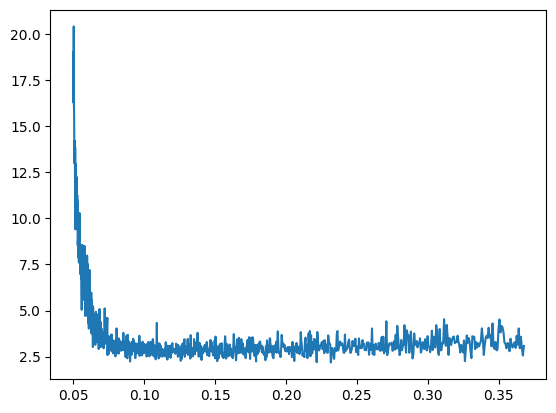

In [201]:
import matplotlib.pyplot as plt
plt.plot(learning_rate, losses)

In [252]:
# while this method has a very high probability to overfit so we need to split all the data into three parts
import numpy as np
words_permutation = np.random.permutation(words)
# print(words[:10])
# print(words_permutation[:10])
def build_datasets(data):
    build_size = 3
    X, Y = [], []
    for w in data:
        chs = w + '.'
        context = [0] * build_size
        for i in chs:
            ix = stoi[i]
            X.append(context)
            Y.append(ix)
            # print(''.join([itos[ix] for ix in context]),'----->',i)
            context = context[1:] + [ix]
    return torch.tensor(X).long(),torch.tensor(Y).long()
    
n1 = int(0.8 * len(words_permutation))
n2 = int(0.9 * len(words_permutation))
Xtr, Ytr = build_datasets(words_permutation[:n1])
Xdev, Ydev = build_datasets(words_permutation[n1:n2])
Xte, Yte = build_datasets(words_permutation[n2:])


In [255]:
g = torch.Generator().manual_seed(217483647)
C = torch.randn(size=(27,10), generator= g)
W1 = torch.randn(size=[30,200], generator= g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn(size=(200,27), generator= g)
b2 = torch.randn(27, generator= g)
params = [C, W1, b1, W2, b2] #### 注意 C也被更新了
sum([p.nelement() for p in params])

11897

In [ ]:
# learning_rate = []
# losses = []
for p in params:
    p.requires_grad = True
for epoch in range(1000):
    for p in params:
        p.grad = None
    ix = torch.randint(low=0, high=Xtr.size(0), size=(32,))
    emb = C[X][ix]
    h = torch.tanh(emb.view(emb.size(0), -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    losses.append(loss.detach().item())
    print(loss.item())
    loss.backward()
    # lr = lrs[epoch]
    # learning_rate.append(lr)
    for p in params:
        p.data -= 0.01 *p.grad
print(loss.item())

In [249]:
emb = C[Xdev]
h = torch.tanh(emb.view(emb.size(0), -1) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.8812172412872314

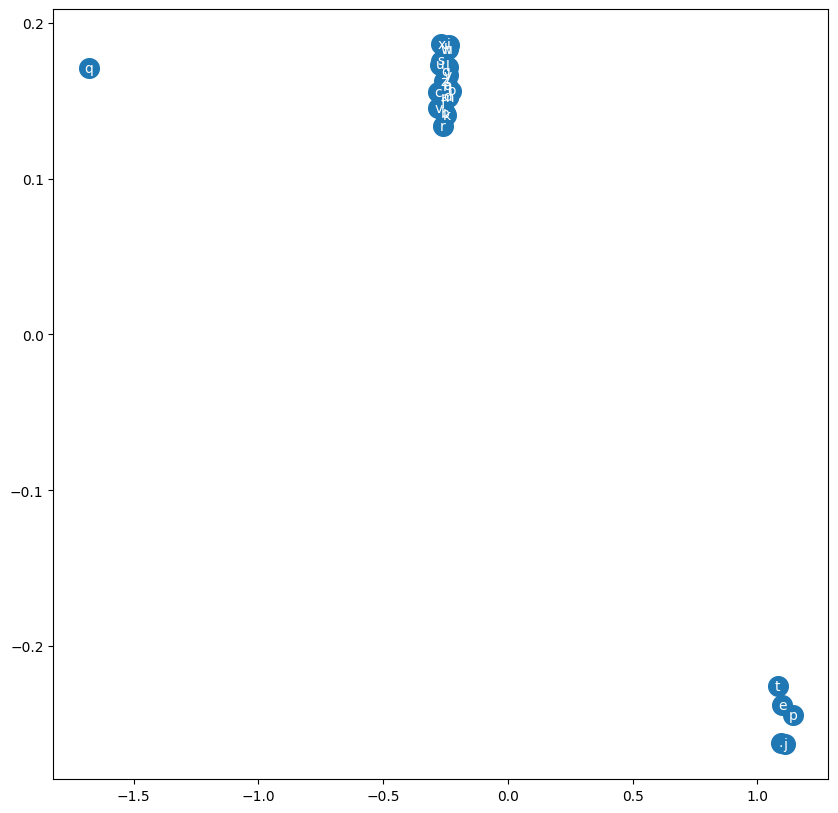

In [251]:
plt.figure(figsize=(10,10))
plt.scatter(C[:,0].detach().numpy(),C[:,1].detach().numpy(), s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')